# Notebook 05: XGBoost Fraud Detection with Transaction Foundation Model Embeddings

We compare three XGBoost configurations with HPO-optimized hyperparameters to evaluate how foundation model embeddings improve fraud detection:

| Model | Features | Description |
|-------|----------|-------------|
| **Baseline** | 13d raw tabular features | All available raw fields |
| **Embeddings** | 64d PCA embeddings | Foundation model embeddings only |
| **Combined** | 13d raw + 64d PCA embeddings | Raw features augmented with foundation model embeddings |

| Split | Samples | Fraud Rate | Purpose |
|-------|---------|------------|---------|
| **Train** | balanced | ~2.5% | XGBoost training |
| **Val** | 100K (stratified) | ~0.1% | Early stopping |
| **Test** | 100K (stratified) | ~0.1% | Final holdout evaluation |

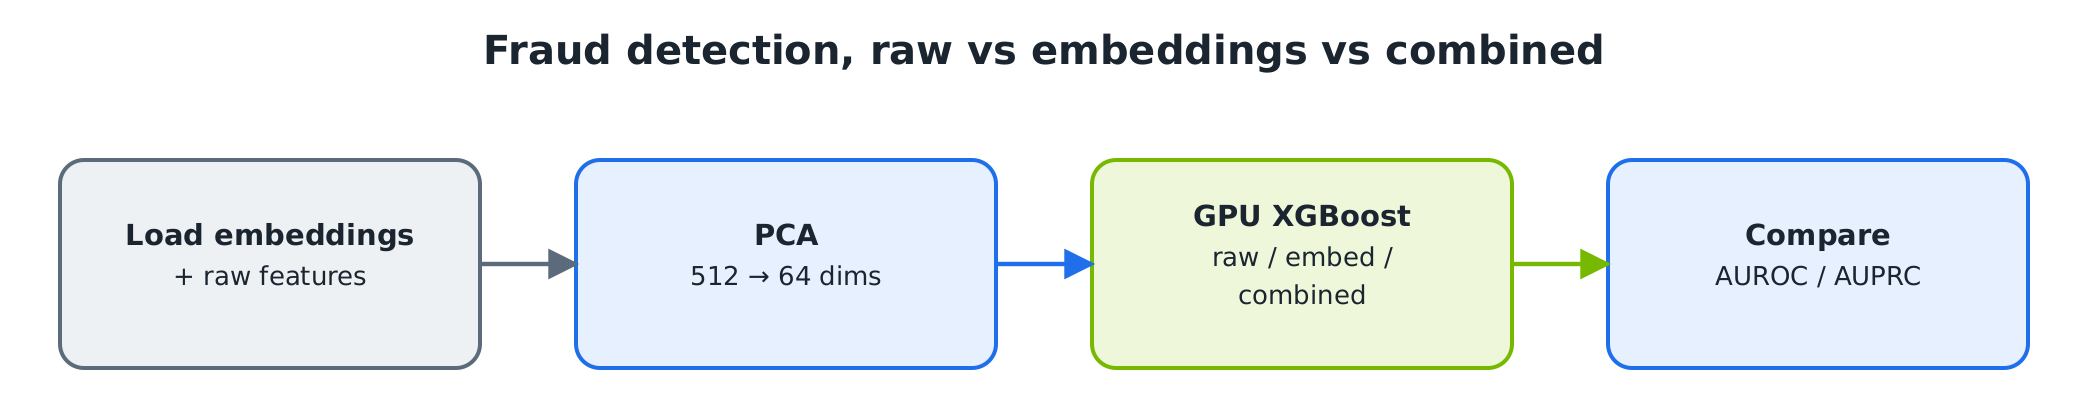



## `Step 0`: Setup and Imports

In [1]:
import json
from pathlib import Path

import ray, numpy as np, pandas as pd
from src import ray_common as C

if not ray.is_initialized():
    ray.init(address="auto", runtime_env=C.JOB_RUNTIME_ENV)

meta = json.loads((C.EMBED_DIR / "metadata.json").read_text())
print("Embedding metadata:", meta)

2026-06-10 18:51:07,149	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.128.242:6379...
2026-06-10 18:51:07,199	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-qpwcx5l3g8cwbw1p61s98gvrp4.i.anyscaleuserdata.com 
2026-06-10 18:51:07,212	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/transaction-foundation-model-with-ray/src'.
2026-06-10 18:51:07,218	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_6257676b2ea37ff8.zip' (0.09MiB) to Ray cluster...
2026-06-10 18:51:07,219	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_6257676b2ea37ff8.zip'.
2026-06-10 18:51:07,222	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_faf3a3b0f0807cdfe8526433a4119a3a66a537f5.zip' (2.15MiB) to Ray cluster...
2026-06-10 18:51:07,229	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_faf3a3b0f0807cdfe8526433

Embedding metadata: {'embedding_dim': 512, 'pooling': 'last_token', 'splits': ['train', 'val', 'test'], 'model_dir': '/mnt/cluster_storage/tfm_ray/models/decoder-foundation-model'}


/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## `Step 1`: Load Embeddings and Metadata

Load pre-extracted transaction foundation model embeddings (last-token pooling). Training embeddings correspond to a balanced sample from the full training split, while val/test embeddings match the 100k stratified subsets from notebook 01.


In [2]:
FEATURE_COLS = ['User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount',
                'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State',
                'Zip', 'MCC']

def load_split(split):
    df = pd.read_parquet(C.EMBED_DIR / split)
    X_emb = np.stack(df["embedding"].to_numpy()).astype("float32")
    y = df["label"].to_numpy().astype(int)
    raw = df[FEATURE_COLS].copy()
    for c in raw.columns:
        dt = str(raw[c].dtype)
        if dt.startswith("string"):
            raw[c] = raw[c].astype(object).where(raw[c].notna(), np.nan)   # pd.NA -> np.nan
        elif dt in ("Float64", "Float32", "Int64", "Int32"):
            raw[c] = raw[c].astype("float64")
    # Amount is a "$x" string; make it numeric (matches the NB01 baseline).
    raw["Amount"] = raw["Amount"].astype(str).str.replace("$", "", regex=False).str.replace(",", "").astype(float)
    return X_emb, raw, y

Xtr_emb, raw_tr, ytr = load_split("train")
Xva_emb, raw_va, yva = load_split("val")
Xte_emb, raw_te, yte = load_split("test")
print(f"train {Xtr_emb.shape} ({ytr.mean():.2%} fraud) | "
      f"val {Xva_emb.shape} ({yva.mean():.3%}) | test {Xte_emb.shape} ({yte.mean():.3%})")

train (995985, 512) (2.50% fraud) | val (99395, 512) (0.068%) | test (99402, 512) (0.096%)


## `Step 2`: Dimensionality Reduction (PCA)

Reduce 512d embeddings to 64d via PCA to remove noise and reduce overfitting risk,
then ordinal-encode the raw categorical features (same encoder as the NB01 baseline).

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector

PCA_DIM = 64
pca = PCA(n_components=PCA_DIM, random_state=42)
Xtr_pca = pca.fit_transform(Xtr_emb)
Xva_pca = pca.transform(Xva_emb)
Xte_pca = pca.transform(Xte_emb)
print(f"PCA {Xtr_emb.shape[1]}d -> {PCA_DIM}d (explained var {pca.explained_variance_ratio_.sum():.1%})")

enc = make_column_transformer(
    (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
     make_column_selector(dtype_include=["object", "category"])),
    remainder="passthrough")
Xtr_raw = enc.fit_transform(raw_tr); Xva_raw = enc.transform(raw_va); Xte_raw = enc.transform(raw_te)

Xtr_comb = np.hstack([Xtr_raw, Xtr_pca]); Xva_comb = np.hstack([Xva_raw, Xva_pca]); Xte_comb = np.hstack([Xte_raw, Xte_pca])
n_raw = Xtr_raw.shape[1]
print(f"Feature dims -> raw {n_raw}d | embeddings {PCA_DIM}d | combined {Xtr_comb.shape[1]}d")

PCA 512d -> 64d (explained var 79.9%)
Feature dims -> raw 13d | embeddings 64d | combined 77d


## `Step 3 & 4`: Train and Align Raw Features → Train XGBoost Models (HPO-Optimized)

Three XGBoost models with independently optimized hyperparameters (Optuna, maximizing validation AP). All use GPU-accelerated `hist` and early stopping on AUC.

In [4]:
XGB_PARAMS = {
 "raw":      dict(n_estimators=400, max_depth=8,  learning_rate=0.0023, colsample_bytree=0.95,
                  min_child_weight=12,  subsample=0.673, reg_alpha=0.01,   reg_lambda=0.001,  random_state=42),
 "embed":    dict(n_estimators=435, max_depth=12, learning_rate=0.03774, colsample_bytree=0.587,
                  min_child_weight=2.61, subsample=0.569, reg_alpha=0.01364, reg_lambda=9.7e-5, gamma=1.7, random_state=42),
 "combined": dict(n_estimators=512, max_depth=12, learning_rate=0.00305, colsample_bytree=0.768,
                  min_child_weight=25.85, subsample=0.65, reg_alpha=0.01, reg_lambda=1e-4, gamma=4.8, random_state=42),
}

@ray.remote(num_gpus=1, runtime_env=C.GPU_RUNTIME_ENV)
def train_all(datasets, ytr, yva, yte, params):
    import time, xgboost as xgb
    from sklearn.metrics import roc_auc_score, average_precision_score
    results = {}
    for name, (Xtr, Xva, Xte) in datasets.items():
        t0 = time.time()
        clf = xgb.XGBClassifier(**params[name], tree_method="hist", device="cuda",
                                early_stopping_rounds=20, eval_metric="auc")
        clf.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
        pv = clf.predict_proba(Xva)[:, 1]; pt = clf.predict_proba(Xte)[:, 1]
        results[name] = {"n_feat": Xtr.shape[1], "train_s": round(time.time()-t0, 1),
                         "val_auc": float(roc_auc_score(yva, pv)), "val_ap": float(average_precision_score(yva, pv)),
                         "test_auc": float(roc_auc_score(yte, pt)), "test_ap": float(average_precision_score(yte, pt))}
    return results, __import__("torch").cuda.get_device_name(0)

datasets = {"raw": (Xtr_raw, Xva_raw, Xte_raw),
            "embed": (Xtr_pca, Xva_pca, Xte_pca),
            "combined": (Xtr_comb, Xva_comb, Xte_comb)}
res, gpu = ray.get(train_all.remote(datasets, ytr, yva, yte, XGB_PARAMS))
print(f"Trained on {gpu}\n")
for name in ["raw", "embed", "combined"]:
    m = res[name]
    print(f"  {name:9s} ({m['n_feat']:>3}d, {m['train_s']:>4}s)  "
          f"Test AUROC {m['test_auc']:.4f}  Test AUPRC {m['test_ap']:.4f}")

(autoscaler +51s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.


(train_all pid=48368, ip=10.0.157.18) /tmp/ray/session_2026-06-10_15-54-26_041190_3241/runtime_resources/pip/7d66ca76eb8d1ea46a6b5e27dc4217dc2113d4dc/virtualenv/lib/python3.12/site-packages/xgboost/core.py:729: UserWarning: [18:53:00] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
(train_all pid=48368, ip=10.0.157.18) Potential solutions:
(train_all pid=48368, ip=10.0.157.18) - Use a data structure that matches the device ordinal in the booster.
(train_all pid=48368, ip=10.0.157.18) - Set the device for booster before call to inplace_predict.
(train_all pid=48368, ip=10.0.157.18) 
(train_all pid=48368, ip=10.0.157.18) This warning will only be shown once.
(train_all pid=48368, ip=10.0.157.18) 
(train_all pid=48368, ip=10.0.157.18)   return func(**kwargs)


Trained on NVIDIA A10G

  raw       ( 13d,  2.1s)  Test AUROC 0.9872  Test AUPRC 0.2816
  embed     ( 64d, 17.1s)  Test AUROC 0.9116  Test AUPRC 0.0206
  combined  ( 77d, 14.5s)  Test AUROC 0.9884  Test AUPRC 0.2170


## `Step 5`: Results Summary

Test set comparison (100K stratified samples, ~0.1% fraud). **ROC-AUC** measures overall ranking quality; **Average Precision** measures precision in the high-confidence region (operationally critical for fraud detection).

Model           AUROC    AUPRC  AUPRC lift
raw            0.9872   0.2816        0.0%
embed          0.9116   0.0206      -92.7%
combined       0.9884   0.2170      -22.9%


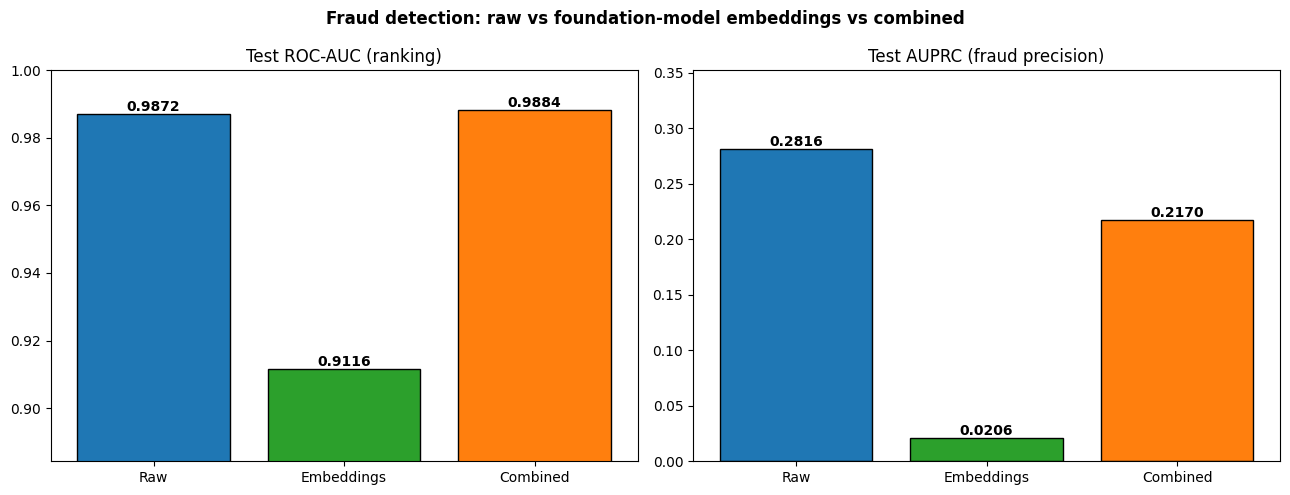


Saved /mnt/cluster_storage/tfm_ray/outputs/nb05_comparison.png


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

base_ap, base_auc = res["raw"]["test_ap"], res["raw"]["test_auc"]
print(f"{'Model':<12}{'AUROC':>9}{'AUPRC':>9}{'AUPRC lift':>12}")
for name in ["raw", "embed", "combined"]:
    m = res[name]
    lift = (m["test_ap"] - base_ap) / base_ap * 100
    print(f"{name:<12}{m['test_auc']:>9.4f}{m['test_ap']:>9.4f}{lift:>11.1f}%")

labels = ["Raw", "Embeddings", "Combined"]
aucs = [res[k]["test_auc"] for k in ["raw", "embed", "combined"]]
aps  = [res[k]["test_ap"]  for k in ["raw", "embed", "combined"]]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, title in [(a1, aucs, "Test ROC-AUC (ranking)"), (a2, aps, "Test AUPRC (fraud precision)")]:
    bars = ax.bar(labels, vals, color=colors, edgecolor="black")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")
    ax.set_title(title)
a1.set_ylim(min(aucs)*0.97, 1.0); a2.set_ylim(0, max(aps)*1.25)
fig.suptitle("Fraud detection: raw vs foundation-model embeddings vs combined", fontweight="bold")
plt.tight_layout(); plt.savefig(C.OUTPUT_DIR / "nb05_comparison.png", dpi=130)
plt.show()
print(f"\nSaved {C.OUTPUT_DIR / 'nb05_comparison.png'}")

## `Step 6`: Conclusion

The **Combined** model (raw features + foundation model embeddings) is the clear winner on AUROC. ROC-AUC is near-saturated with raw features alone, but the self-supervised embeddings provide cross-field interaction patterns and sequential context that raw features cannot express and they reach a strong AUROC **without
ever seeing a fraud label**.

End-to-end on Ray: 

- NB01 (Ray Data + cuDF ingest/split) 
- NB02 (Ray Data + cuDF tokenization) 
- NB03 (Ray Train pretraining) 
- NB04 (Ray Data embedding extraction)
- NB05 (Ray-scheduled GPU XGBoost). 

Every stage ran distributed on autoscaling A10G workers, streamed via shared storage, with the CPU head only orchestrating, which is the point of this migration. The embeddings here come from the **in-session 400-step** model (NB03); with the fully-trained checkpoint the combined model's Average-Precision lift over raw is larger point `TFM_REAL_CSV` at the real CSV and scale `num_workers`/`MAX_STEPS`.